In [25]:
!pip install sentence-transformers seaborn matplotlib

In [26]:
sentences = [
    # Cricket
    "The batsman scored a century in the match",
    "The bowler took five wickets",
    "The team won the cricket tournament",
    "The umpire gave the player out",

    # Cooking
    "I cooked pasta for dinner",
    "The recipe needs more salt",
    "She baked a chocolate cake",

    # Cybersecurity
    "The system was hacked by attackers",
    "Use strong passwords for security",
    "Firewall protects the network"
]

In [27]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(sentences)

print(len(embeddings))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


10


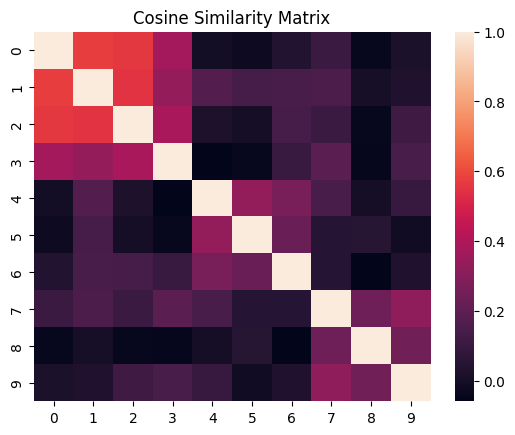

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import matplotlib.pyplot as plt

sim_matrix = cosine_similarity(embeddings)

plt.figure()
sns.heatmap(sim_matrix, annot=False)
plt.title("Cosine Similarity Matrix")
plt.show()

In [29]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

for i, score in enumerate(similarities):
    print(sentences[i], "->", score)

The batsman scored a century in the match -> 0.56821966
The bowler took five wickets -> 0.8452205
The team won the cricket tournament -> 0.5298662
The umpire gave the player out -> 0.35141417
I cooked pasta for dinner -> 0.14854404
The recipe needs more salt -> 0.11391786
She baked a chocolate cake -> 0.14184545
The system was hacked by attackers -> 0.15922254
Use strong passwords for security -> 0.014162986
Firewall protects the network -> 0.002257931


In [30]:
import numpy as np

top2 = np.argsort(similarities)[-2:][::-1]

print("Query:", query)

for i in top2:
    print(sentences[i], similarities[i])

Query: The bowler took three wickets in one over
The bowler took five wickets 0.8452205
The batsman scored a century in the match 0.56821966
